<a href="https://colab.research.google.com/github/aronnaiqbal/220153-KNN/blob/main/220153_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

In [ ]:
url = "https://raw.githubusercontent.com/aronnaiqbal/220153-KNN/refs/heads/main/dataset/Titanic-Dataset.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
d

In [ ]:
df.head()
df.shape

(891, 12)

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


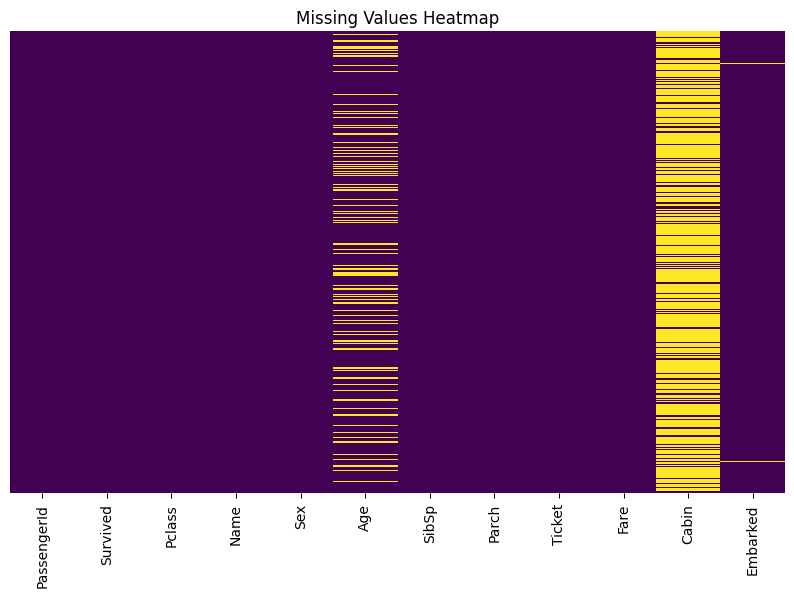

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False,
            cmap='viridis')

plt.title("Missing Values Heatmap")
plt.show()

/tmp/ipykernel_4507/1474361125.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='coolwarm')


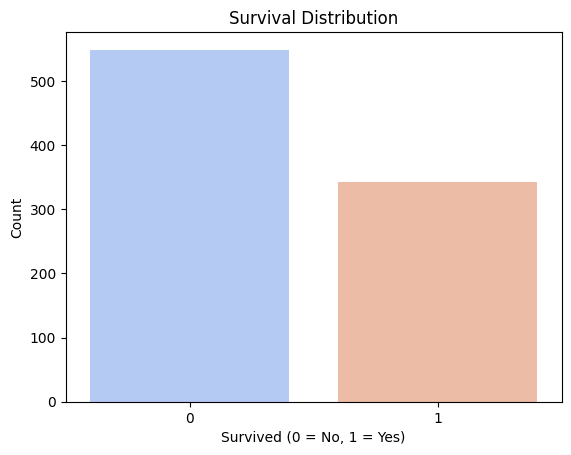

In [ ]:
sns.countplot(x='Survived', data=df, palette='coolwarm')

plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

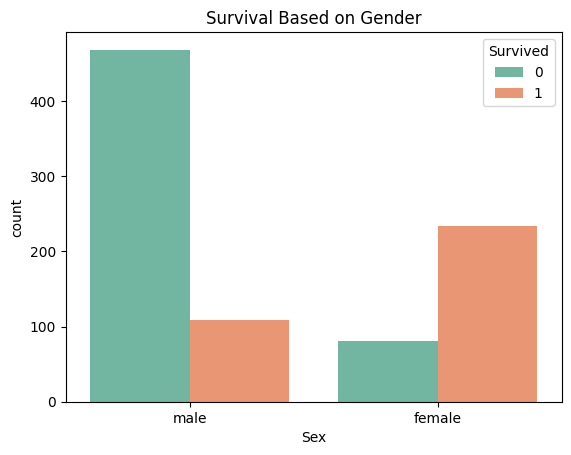

In [ ]:
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2')

plt.title("Survival Based on Gender")
plt.show()

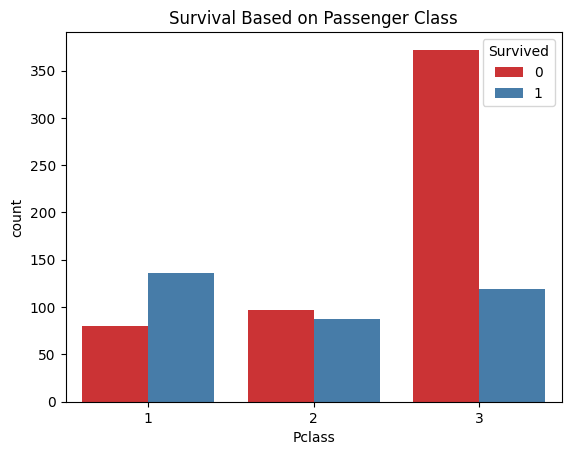

In [ ]:
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set1')

plt.title("Survival Based on Passenger Class")
plt.show()

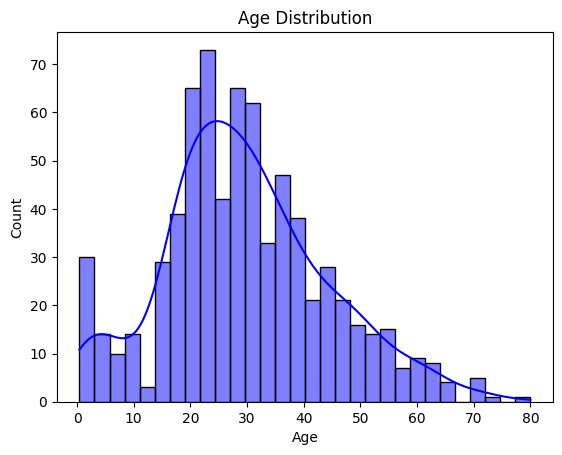

In [ ]:
sns.histplot(df['Age'], bins=30, kde=True, color='blue')

plt.title("Age Distribution")
plt.show()

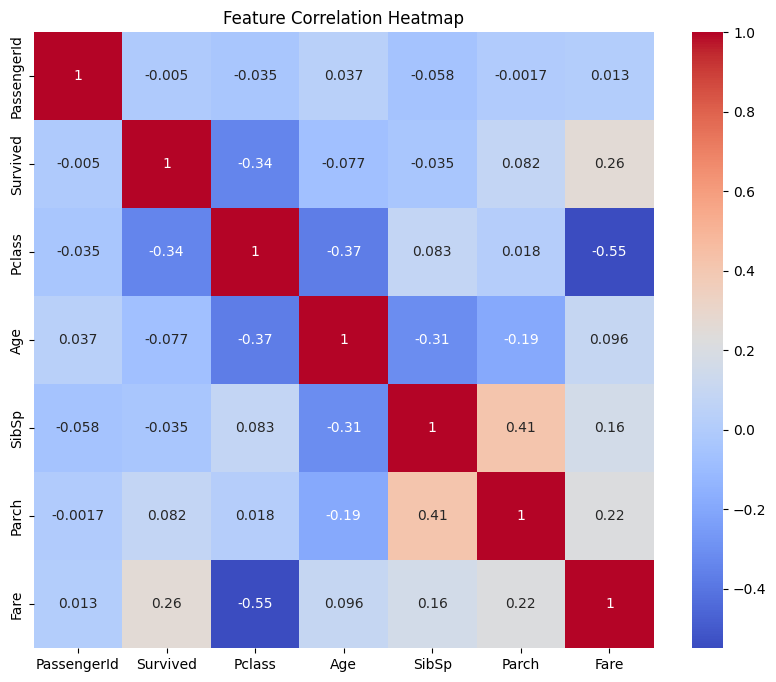

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
columns_to_drop = ['PassengerId','Name','Ticket','Cabin']

df.drop(columns=columns_to_drop,
        inplace=True,
        errors='ignore')

In [ ]:
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[['Age']] = num_imputer.fit_transform(df[['Age']])
df[['Embarked']] = cat_imputer.fit_transform(df[['Embarked']])

In [ ]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

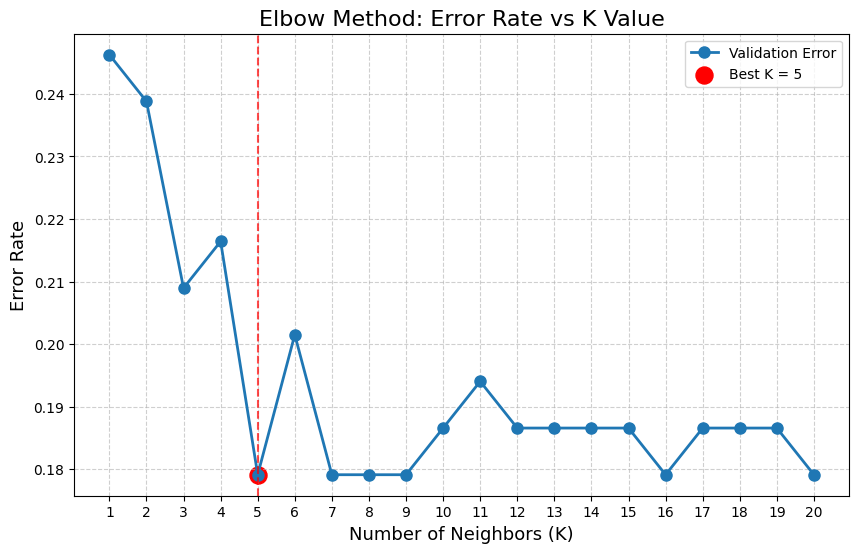

Best K: 5
Minimum Error: 0.1791044776119403


In [ ]:
error_rate = []

# Test K from 1 to 20
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_val)
    error_rate.append(np.mean(pred != y_val))

# Find best k (minimum error)
best_k = np.argmin(error_rate) + 1
min_error = min(error_rate)

# Plot
plt.figure(figsize=(10,6))

plt.plot(
    range(1,21),
    error_rate,
    marker='o',
    markersize=8,
    linewidth=2,
    label='Validation Error'
)

# Highlight best K
plt.scatter(best_k,
            min_error,
            s=150,
            color='red',
            label=f'Best K = {best_k}')

plt.axvline(x=best_k,
            linestyle='--',
            color='red',
            alpha=0.7)

plt.title("Elbow Method: Error Rate vs K Value", fontsize=16)
plt.xlabel("Number of Neighbors (K)", fontsize=13)
plt.ylabel("Error Rate", fontsize=13)

plt.xticks(range(1,21))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.savefig("Elbow_Method_KNN.png", dpi=300, bbox_inches='tight')

plt.show()

print("Best K:", best_k)
print("Minimum Error:", min_error)

In [ ]:
param_grid = {
    'n_neighbors': list(range(1,20)),
    'weights': ['uniform','distance'],
    'metric': ['minkowski','euclidean','manhattan']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'metric': 'manhattan', 'n_neighbors': 16, 'weights': 'uniform'}


In [ ]:
best_knn = grid.best_estimator_

In [ ]:
y_pred = best_knn.predict(X_test)
y_prob = best_knn.predict_proba(X_test)[:,1]

In [ ]:
print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1:", f1_score(y_test,y_pred))
print("AUC:", roc_auc_score(y_test,y_prob))

Accuracy: 0.7910447761194029
Precision: 0.7567567567567568
Recall: 0.5957446808510638
F1: 0.6666666666666666
AUC: 0.8417706040596723


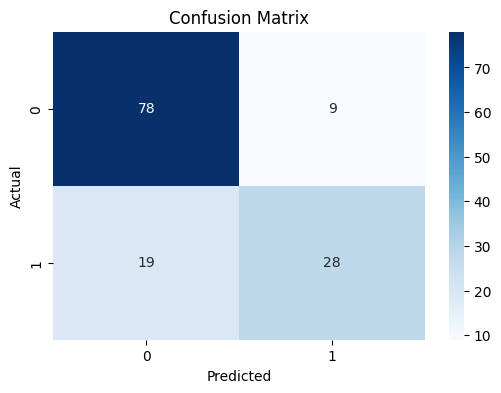

In [ ]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

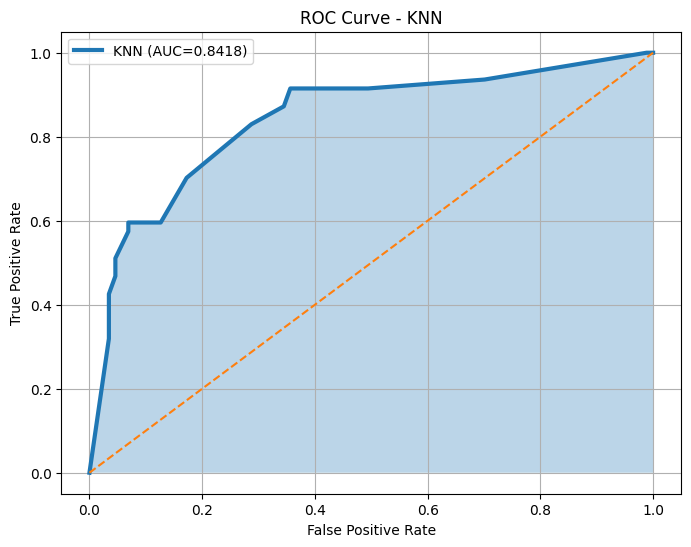

In [ ]:
fpr, tpr, _ = roc_curve(y_test,y_prob)
auc = roc_auc_score(y_test,y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,
         linewidth=3,
         label=f'KNN (AUC={auc:.4f})')

plt.fill_between(fpr,tpr,alpha=0.3)

plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve - KNN")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

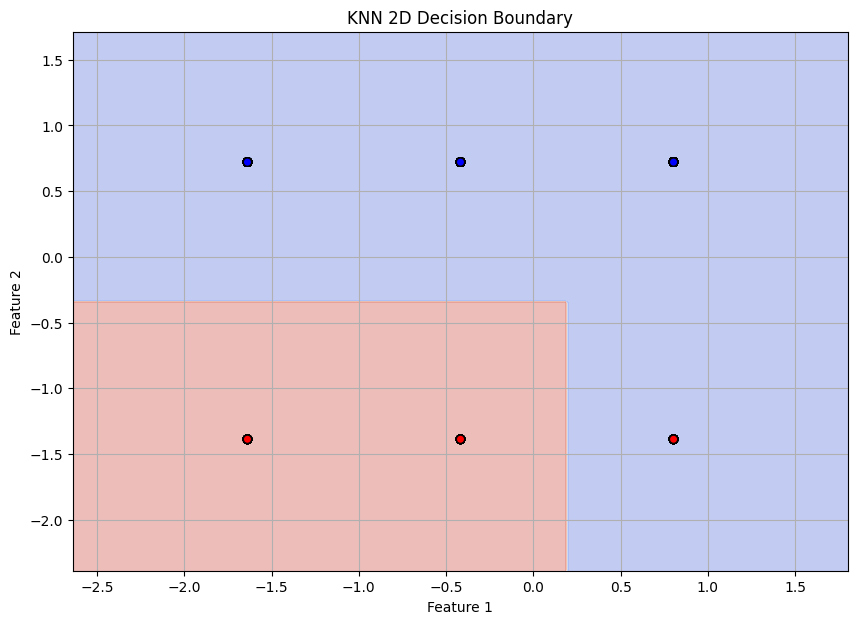

In [ ]:
X_plot = X_train[:, :2]

model_2d = KNeighborsClassifier(
    n_neighbors=grid.best_params_['n_neighbors']
)

model_2d.fit(X_plot,y_train)

x_min, x_max = X_plot[:,0].min()-1, X_plot[:,0].max()+1
y_min, y_max = X_plot[:,1].min()-1, X_plot[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min,x_max,0.02),
    np.arange(y_min,y_max,0.02)
)

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,7))
plt.contourf(xx,yy,Z,
             alpha=0.35,
             cmap='coolwarm')

plt.scatter(
    X_plot[:,0],
    X_plot[:,1],
    c=y_train,
    cmap='bwr',
    edgecolors='black'
)

plt.title("KNN 2D Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid()
plt.show()